# Residual Pattern Analysis — Hybrid Prophet + GRU**Read-only diagnostic notebook.** This study investigates whether Prophetresiduals used during Hybrid GRU training contain meaningful temporal patternsthat justify the residual-learning component of the architecture.> **Scope:** Training cohort containers only (`selected_containers.npy`).> No retraining, no artifact writes, in-memory analysis only.

## Section 1 — Project OverviewThe Hybrid Prophet + GRU pipeline decomposes CPU forecasting into two stages:```CPU Usage (scaled)        ↓    Prophet  →  trend + daily seasonality        ↓Residual = Actual − Prophet        ↓      GRU    →  learns temporal structure in residuals        ↓Final forecast = Prophet + GRU residual correction```**Research question:** After Prophet removes trend and seasonality, do theremaining residuals still contain predictable temporal dependencies that canbe learned by the GRU?This notebook validates that design assumption using statistical diagnostics(ACF, PACF, Ljung–Box), distributional analysis, and comparison with frozenGRU residual predictions on the validation period.

In [32]:
import os
import pickle
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy import stats
from scipy.signal import periodogram
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    from statsmodels.tsa.stattools import acf, pacf
except ImportError as exc:
    raise ImportError(
        "statsmodels is required for ACF/PACF/Ljung–Box analysis. "
        "Install with: pip install statsmodels"
    ) from exc

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sys.path.append(os.path.abspath(".."))

from utils.hybrid_artifacts import load_hybrid_artifacts
from utils.hybrid_config import DAY1_HORIZON, DEFAULT_INPUT_WINDOW
from utils.hybrid_inference import run_hybrid_inference
from utils.hybrid_evaluation import _evaluable_container_ids
from utils.peak_config import BASELINE_REFERENCE_DIR, DATA_SELECTED_CONTAINERS

REPO_ROOT = Path("..").resolve()
INPUT_WINDOW = DEFAULT_INPUT_WINDOW
ROLLING_WINDOW = DAY1_HORIZON  # one day at 15-minute resolution

COLOR_ACTUAL = "#2CA02C"
COLOR_PROPHET = "#DD8452"
COLOR_RESIDUAL = "#8172B2"
COLOR_PRED = "#4C72B0"
COLOR_ZERO = "#7F7F7F"

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

train_df = pd.read_parquet(REPO_ROOT / "data/train_df.parquet")
val_df = pd.read_parquet(REPO_ROOT / "data/val_df.parquet")

with open(REPO_ROOT / "data/scalers.pkl", "rb") as handle:
    scalers = pickle.load(handle)

selected_containers = np.load(DATA_SELECTED_CONTAINERS, allow_pickle=True)

BASELINE_MODEL_DIR = BASELINE_REFERENCE_DIR / "models"
hybrid_gru_model, res_mean, res_std, artifact_input_window = load_hybrid_artifacts(
    model_path=BASELINE_MODEL_DIR / "hybrid_gru.keras",
    residual_stats_path=BASELINE_MODEL_DIR / "residual_stats.pkl",
)
assert artifact_input_window == INPUT_WINDOW

print(f"Repository root          : {REPO_ROOT}")
print(f"Selected containers    : {len(selected_containers)}")
print(f"Frozen Hybrid GRU      : {BASELINE_MODEL_DIR / 'hybrid_gru.keras'}")
print(f"Input window / Day-1   : {INPUT_WINDOW} / {DAY1_HORIZON} steps")


Repository root          : /Users/lehaan/Desktop/FYP_Long_Term
Selected containers    : 100
Frozen Hybrid GRU      : /Users/lehaan/Desktop/FYP_Long_Term/experiments/baseline_reference_2026-07-14/models/hybrid_gru.keras
Input window / Day-1   : 96 / 96 steps


## Section 2 — Container SelectionAnalyse **only** containers from `selected_containers.npy` (Hybrid GRU training cohort).| Mode | Configuration ||------|---------------|| Manual | `MANUAL_CONTAINER = "c_xxxxx"` || Random sample | `SAMPLE_SIZE = 10`, `RANDOM_SEED = 42` (default when manual is `None` and `ANALYSE_ALL = False`) || All selected | `ANALYSE_ALL = True` |

In [33]:
MANUAL_CONTAINER = None
SAMPLE_SIZE = 10
RANDOM_SEED = 42
ANALYSE_ALL = True

evaluable_containers, skipped_containers = _evaluable_container_ids(
    selected_containers=selected_containers,
    global_train=train_df,
    global_val=val_df,
    scalers=scalers,
    min_train_steps=INPUT_WINDOW,
)

if skipped_containers:
    print("Skipped containers:")
    for cid, reason in skipped_containers:
        print(f"  {cid}: {reason}")

if MANUAL_CONTAINER is not None:
    selection_mode = "manual"
    if MANUAL_CONTAINER not in evaluable_containers:
        raise ValueError(
            f"Manual container {MANUAL_CONTAINER!r} is not evaluable. "
            f"Choose from selected_containers.npy with sufficient train/val data."
        )
    analysed_containers = [str(MANUAL_CONTAINER)]
elif ANALYSE_ALL:
    selection_mode = "all selected"
    analysed_containers = list(evaluable_containers)
else:
    selection_mode = f"random sample (n={SAMPLE_SIZE})"
    rng = np.random.default_rng(RANDOM_SEED)
    sample_n = min(SAMPLE_SIZE, len(evaluable_containers))
    analysed_containers = sorted(
        rng.choice(evaluable_containers, size=sample_n, replace=False).tolist()
    )

REPRESENTATIVE_CONTAINER = analysed_containers[0]

print(f"Selection mode           : {selection_mode}")
print(f"Number analysed          : {len(analysed_containers)}")
print(f"Representative container : {REPRESENTATIVE_CONTAINER}")
print(f"Container IDs            : {analysed_containers}")

for cid in analysed_containers:
    n_train = int((train_df["container_id"] == cid).sum())
    n_val = int((val_df["container_id"] == cid).sum())
    print(f"  {cid}: train={n_train}, val={n_val}")


Skipped containers:
  c_14674: missing from frozen train/val data
Selection mode           : all selected
Number analysed          : 99
Representative container : c_10032
Container IDs            : ['c_10032', 'c_10034', 'c_10089', 'c_10132', 'c_1016', 'c_10306', 'c_10312', 'c_10382', 'c_10393', 'c_10641', 'c_10695', 'c_10733', 'c_10878', 'c_10898', 'c_11013', 'c_11087', 'c_11203', 'c_11307', 'c_11327', 'c_11461', 'c_11735', 'c_11752', 'c_1181', 'c_1186', 'c_11996', 'c_12060', 'c_12158', 'c_12164', 'c_12174', 'c_12189', 'c_12193', 'c_12231', 'c_12237', 'c_12441', 'c_12517', 'c_12624', 'c_12767', 'c_12858', 'c_1286', 'c_12971', 'c_12974', 'c_12993', 'c_12999', 'c_13020', 'c_13044', 'c_13083', 'c_13166', 'c_13170', 'c_13229', 'c_13269', 'c_13308', 'c_13389', 'c_13403', 'c_13441', 'c_13607', 'c_13615', 'c_13658', 'c_13690', 'c_1379', 'c_1387', 'c_13873', 'c_14106', 'c_14135', 'c_14296', 'c_14363', 'c_14388', 'c_14396', 'c_14413', 'c_14416', 'c_14417', 'c_14435', 'c_14471', 'c_14820', 'c_1

## Section 3 — Prophet TrainingFor each selected container, fit Prophet on the **training period only**(`daily_seasonality=True`, `weekly_seasonality=False` — matching the Hybridpipeline), forecast the **validation period**, and compute residuals in realCPU percent: `Actual − Prophet`.

In [34]:
def fit_prophet_and_residuals(container_id: str) -> dict:
    """Fit Prophet on train, forecast val, return residual diagnostics."""
    train_container = train_df[train_df["container_id"] == container_id].sort_values("time_stamp")
    val_container = val_df[val_df["container_id"] == container_id].sort_values("time_stamp")

    prophet_train = pd.DataFrame({
        "ds": train_container["time_stamp"],
        "y": train_container["cpu_scaled"],
    })

    prophet_model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=False,
    )
    prophet_model.fit(prophet_train)

    future_df = pd.DataFrame({"ds": val_container["time_stamp"].values})
    forecast = prophet_model.predict(future_df)

    scaler = scalers[container_id]
    actual_scaled = val_container["cpu_scaled"].values
    prophet_scaled = forecast["yhat"].values

    actual_real = scaler.inverse_transform(actual_scaled.reshape(-1, 1)).ravel()
    prophet_real = scaler.inverse_transform(prophet_scaled.reshape(-1, 1)).ravel()
    residual_real = actual_real - prophet_real

    residual_scaled = actual_scaled - prophet_scaled

    return {
        "container_id": container_id,
        "train_container": train_container,
        "val_container": val_container,
        "prophet_model": prophet_model,
        "timestamps": val_container["time_stamp"].values,
        "actual_real": actual_real,
        "prophet_real": prophet_real,
        "residual_real": residual_real,
        "residual_scaled": residual_scaled,
        "prophet_mae": float(mean_absolute_error(actual_real, prophet_real)),
        "prophet_rmse": float(np.sqrt(mean_squared_error(actual_real, prophet_real))),
        "n_train": len(train_container),
        "n_val": len(val_container),
    }


container_results: dict[str, dict] = {}
for cid in analysed_containers:
    container_results[cid] = fit_prophet_and_residuals(cid)

print(f"Prophet fitted for {len(container_results)} containers.")
print(f"{'Container':<12} {'Prophet MAE':>12} {'Prophet RMSE':>13} {'Val steps':>10}")
for cid in analysed_containers:
    r = container_results[cid]
    print(f"{cid:<12} {r['prophet_mae']:12.4f} {r['prophet_rmse']:13.4f} {r['n_val']:10d}")


00:55:19 - cmdstanpy - INFO - Chain [1] start processing
00:55:19 - cmdstanpy - INFO - Chain [1] done processing
00:55:19 - cmdstanpy - INFO - Chain [1] start processing
00:55:19 - cmdstanpy - INFO - Chain [1] done processing
00:55:19 - cmdstanpy - INFO - Chain [1] start processing
00:55:19 - cmdstanpy - INFO - Chain [1] done processing
00:55:19 - cmdstanpy - INFO - Chain [1] start processing
00:55:20 - cmdstanpy - INFO - Chain [1] done processing
00:55:20 - cmdstanpy - INFO - Chain [1] start processing
00:55:20 - cmdstanpy - INFO - Chain [1] done processing
00:55:20 - cmdstanpy - INFO - Chain [1] start processing
00:55:20 - cmdstanpy - INFO - Chain [1] done processing
00:55:20 - cmdstanpy - INFO - Chain [1] start processing
00:55:20 - cmdstanpy - INFO - Chain [1] done processing
00:55:20 - cmdstanpy - INFO - Chain [1] start processing
00:55:20 - cmdstanpy - INFO - Chain [1] done processing
00:55:20 - cmdstanpy - INFO - Chain [1] start processing
00:55:20 - cmdstanpy - INFO - Chain [1]

Prophet fitted for 99 containers.
Container     Prophet MAE  Prophet RMSE  Val steps
c_10032            0.6989        0.8776        154
c_10034            3.0601        3.6278        154
c_10089            0.7219        0.9719        154
c_10132            0.6273        0.7726        153
c_1016             0.3179        0.4532        154
c_10306            0.3399        0.3987        154
c_10312            0.3576        0.4741        154
c_10382            0.5179        0.7230        154
c_10393            1.5304        1.8885        154
c_10641            0.6856        0.9172        154
c_10695            0.6136        0.8607        154
c_10733            1.9280        2.4374        153
c_10878            0.4350        0.5972        154
c_10898            0.6156        0.8212        154
c_11013            3.0039        4.4370        154
c_11087            7.0426       12.4408        154
c_11203            1.4641        2.2101        154
c_11307            2.4551        3.9531        1

## Section 4 — Residual Time SeriesVisualise validation-period residuals for the **representative container**.A structured residual series (persistence, bursts, oscillations) suggestsremaining temporal information beyond Prophet's decomposition.

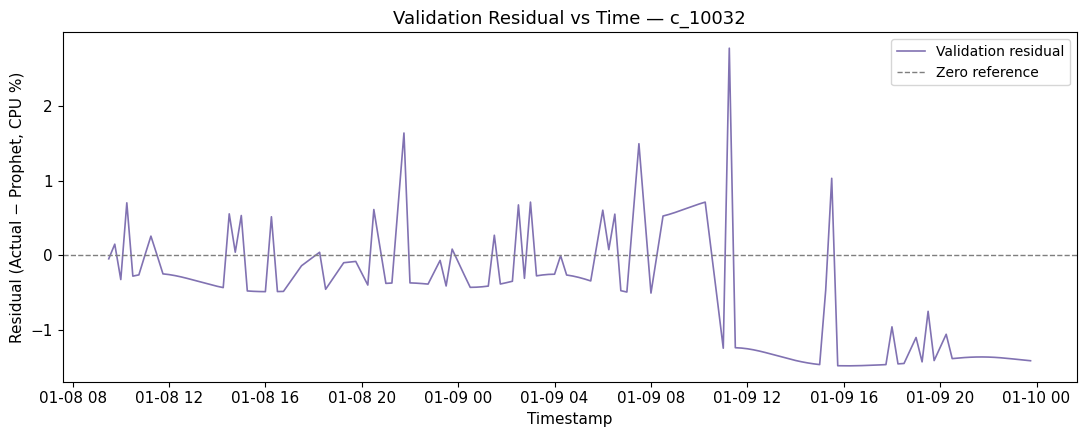

Sign persistence (lag-1 same sign): 0.778
Residual range: [-1.474, 2.767] %


In [37]:
rep = container_results[REPRESENTATIVE_CONTAINER]
residuals = rep["residual_real"]
timestamps = rep["timestamps"]

fig, ax = plt.subplots()
ax.plot(timestamps, residuals, color=COLOR_RESIDUAL, linewidth=1.2, label="Validation residual")
ax.axhline(0.0, color=COLOR_ZERO, linestyle="--", linewidth=1.0, label="Zero reference")
ax.set_title(f"Validation Residual vs Time — {REPRESENTATIVE_CONTAINER}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Residual (Actual − Prophet, CPU %)")
ax.legend()
plt.tight_layout()
plt.show()

finite = residuals[np.isfinite(residuals)]
sign_persistence = np.mean(np.sign(finite[1:]) == np.sign(finite[:-1])) if len(finite) > 1 else np.nan
print(f"Sign persistence (lag-1 same sign): {sign_persistence:.3f}")
print(f"Residual range: [{np.nanmin(residuals):.3f}, {np.nanmax(residuals):.3f}] %")


**Interpretation (Section 4):** Inspect whether residuals cluster above/below zero(persistence), show short bursts of large error, or oscillate with visible rhythm.Pure white noise would appear as rapid, mean-reverting fluctuations around zerowithout sustained runs or periodic structure.

## Section 5 — Residual DistributionAggregate validation residuals across **all analysed containers** andcharacterise the pooled distribution.

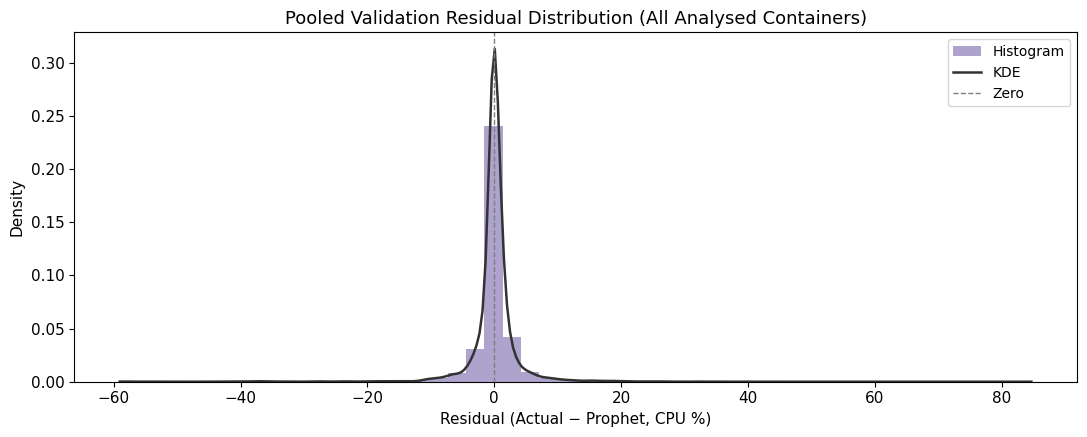

Pooled residual statistics (CPU %):
  Mean      : -0.0302
  Median    : -0.0063
  Std       :  4.4478
  Min       : -59.0682
  Max       :  84.7010
  Skewness  : -2.5353
  Kurtosis  :  58.0470


In [38]:
all_residuals = np.concatenate([
    container_results[cid]["residual_real"] for cid in analysed_containers
])
all_residuals = all_residuals[np.isfinite(all_residuals)]

dist_stats = {
    "mean": float(np.mean(all_residuals)),
    "median": float(np.median(all_residuals)),
    "std": float(np.std(all_residuals)),
    "min": float(np.min(all_residuals)),
    "max": float(np.max(all_residuals)),
    "skewness": float(stats.skew(all_residuals)),
    "kurtosis": float(stats.kurtosis(all_residuals)),
}

fig, ax = plt.subplots()
ax.hist(all_residuals, bins=50, density=True, alpha=0.65, color=COLOR_RESIDUAL, label="Histogram")
if len(all_residuals) > 1 and np.std(all_residuals) > 0:
    xs = np.linspace(all_residuals.min(), all_residuals.max(), 300)
    kde = stats.gaussian_kde(all_residuals)
    ax.plot(xs, kde(xs), color="#333333", linewidth=1.8, label="KDE")
ax.axvline(0.0, color=COLOR_ZERO, linestyle="--", linewidth=1.0, label="Zero")
ax.set_title("Pooled Validation Residual Distribution (All Analysed Containers)")
ax.set_xlabel("Residual (Actual − Prophet, CPU %)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

print("Pooled residual statistics (CPU %):")
for key, value in dist_stats.items():
    print(f"  {key.capitalize():<10}: {value: .4f}")


**Interpretation (Section 5):** Residuals centered near zero indicate Prophetcaptures the level reasonably well. Symmetry suggests unbiased errors; heavytails (high kurtosis) imply occasional large Prophet misses — potentiallylearnable by a sequence model during peak or burst periods.

## Section 6 — Autocorrelation AnalysisCompute ACF (50 lags) per container on validation residuals. Strongautocorrelation implies temporal dependence remains after Prophet.

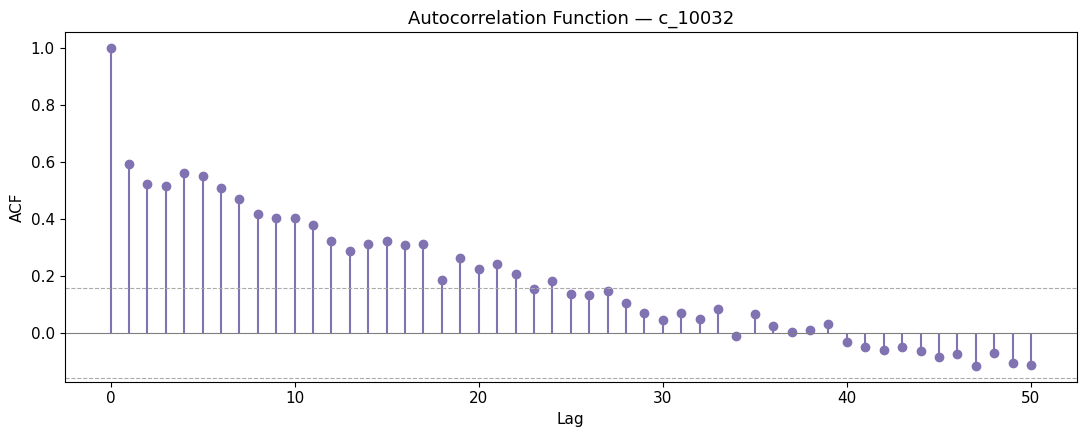

Average |ACF| across containers:
  Lags  1–10 : 0.2010
  Lags 11–20 : 0.1015
  Lags 21–50 : 0.0776


In [39]:
ACF_NLAGS = 50
acf_by_container: dict[str, np.ndarray] = {}

for cid in analysed_containers:
    series = container_results[cid]["residual_real"]
    series = series[np.isfinite(series)]
    if len(series) <= ACF_NLAGS:
        continue
    acf_vals = acf(series, nlags=ACF_NLAGS, fft=True)
    acf_by_container[cid] = acf_vals

rep_acf = acf_by_container[REPRESENTATIVE_CONTAINER]
lags = np.arange(len(rep_acf))

fig, ax = plt.subplots()
ax.stem(lags, rep_acf, linefmt=COLOR_RESIDUAL, markerfmt="o", basefmt=" ")
ax.axhline(0.0, color=COLOR_ZERO, linewidth=0.8)
conf = 1.96 / np.sqrt(len(container_results[REPRESENTATIVE_CONTAINER]["residual_real"]))
ax.axhline(conf, color="#AAAAAA", linestyle="--", linewidth=0.8)
ax.axhline(-conf, color="#AAAAAA", linestyle="--", linewidth=0.8)
ax.set_title(f"Autocorrelation Function — {REPRESENTATIVE_CONTAINER}")
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
plt.tight_layout()
plt.show()


def _avg_abs_acf_range(acf_values: np.ndarray, lag_start: int, lag_end: int) -> float:
    segment = acf_values[lag_start:lag_end + 1]
    return float(np.mean(np.abs(segment)))


acf_summary_rows = []
for cid, acf_vals in acf_by_container.items():
    acf_summary_rows.append({
        "container_id": cid,
        "lag_1_10": _avg_abs_acf_range(acf_vals, 1, 10),
        "lag_11_20": _avg_abs_acf_range(acf_vals, 11, 20),
        "lag_21_50": _avg_abs_acf_range(acf_vals, 21, 50),
    })

acf_summary = pd.DataFrame(acf_summary_rows)
print("Average |ACF| across containers:")
print(f"  Lags  1–10 : {acf_summary['lag_1_10'].mean():.4f}")
print(f"  Lags 11–20 : {acf_summary['lag_11_20'].mean():.4f}")
print(f"  Lags 21–50 : {acf_summary['lag_21_50'].mean():.4f}")


**Interpretation (Section 6):** Elevated |ACF| at short lags (1–10) indicatesshort-term persistence in Prophet errors. Non-negligible |ACF| at longer lagssuggests daily or sub-daily structure Prophet did not fully remove — a targetfor GRU residual learning.

## Section 7 — Partial AutocorrelationPACF isolates direct lag relationships after removing intermediate lag effects.

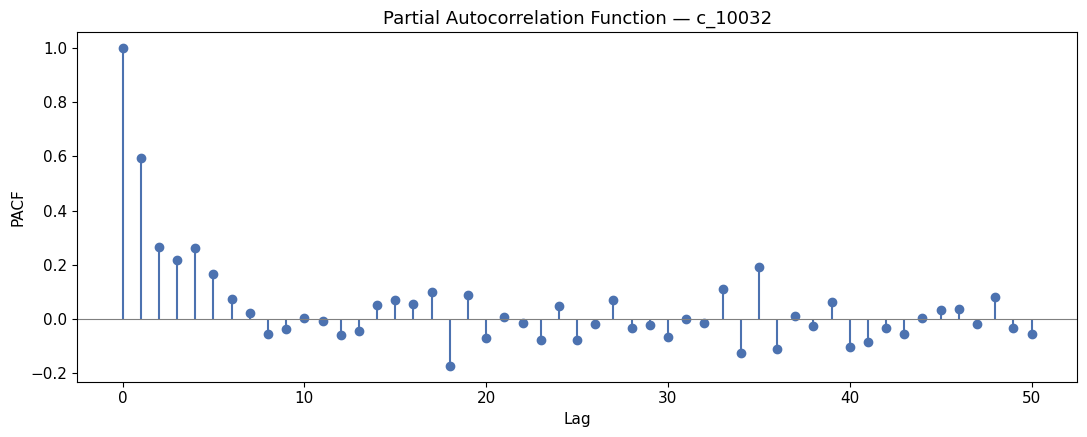

Average |PACF| across containers:
  Lags  1–10 : 0.1088
  Lags 11–20 : 0.0575


In [40]:
pacf_by_container: dict[str, np.ndarray] = {}

for cid in analysed_containers:
    series = container_results[cid]["residual_real"]
    series = series[np.isfinite(series)]
    if len(series) <= ACF_NLAGS:
        continue
    pacf_vals = pacf(series, nlags=ACF_NLAGS, method="ywm")
    pacf_by_container[cid] = pacf_vals

rep_pacf = pacf_by_container[REPRESENTATIVE_CONTAINER]
pacf_lags = np.arange(len(rep_pacf))

fig, ax = plt.subplots()
ax.stem(pacf_lags, rep_pacf, linefmt=COLOR_PRED, markerfmt="o", basefmt=" ")
ax.axhline(0.0, color=COLOR_ZERO, linewidth=0.8)
ax.set_title(f"Partial Autocorrelation Function — {REPRESENTATIVE_CONTAINER}")
ax.set_xlabel("Lag")
ax.set_ylabel("PACF")
plt.tight_layout()
plt.show()

pacf_summary = pd.DataFrame([
    {
        "container_id": cid,
        "pacf_lag_1_10": _avg_abs_acf_range(vals, 1, 10),
        "pacf_lag_11_20": _avg_abs_acf_range(vals, 11, 20),
    }
    for cid, vals in pacf_by_container.items()
])
print("Average |PACF| across containers:")
print(f"  Lags  1–10 : {pacf_summary['pacf_lag_1_10'].mean():.4f}")
print(f"  Lags 11–20 : {pacf_summary['pacf_lag_11_20'].mean():.4f}")


**Interpretation (Section 7):** Significant PACF at low lags confirms directserial dependence in residuals. Multiple significant PACF spikes can indicatemulti-step predictable structure beyond simple AR(1) persistence.

## Section 8 — Ljung–Box TestTest whether residuals are consistent with white noise at 10, 20, and 30 lags.Rejection (p < 0.05) indicates remaining temporal dependence.

In [41]:
LJUNG_LAGS = [10, 20, 30]
ljung_rows = []

for cid in analysed_containers:
    series = container_results[cid]["residual_real"]
    series = series[np.isfinite(series)]
    row = {"container_id": cid}
    for lag in LJUNG_LAGS:
        lb = acorr_ljungbox(series, lags=[lag], return_df=True)
        row[f"lb_stat_lag_{lag}"] = float(lb["lb_stat"].iloc[0])
        row[f"lb_p_lag_{lag}"] = float(lb["lb_pvalue"].iloc[0])
    ljung_rows.append(row)

ljung_df = pd.DataFrame(ljung_rows)

print("Ljung–Box summary (fraction of containers with p < 0.05):")
for lag in LJUNG_LAGS:
    reject_rate = float((ljung_df[f"lb_p_lag_{lag}"] < 0.05).mean())
    print(f"  Lag {lag:2d}: {reject_rate * 100:5.1f}% reject white noise")

print(f"\nRepresentative container ({REPRESENTATIVE_CONTAINER}):")
for lag in LJUNG_LAGS:
    stat = ljung_df.loc[ljung_df["container_id"] == REPRESENTATIVE_CONTAINER, f"lb_stat_lag_{lag}"].iloc[0]
    pval = ljung_df.loc[ljung_df["container_id"] == REPRESENTATIVE_CONTAINER, f"lb_p_lag_{lag}"].iloc[0]
    print(f"  Lag {lag:2d}: statistic={stat:.3f}, p-value={pval:.4g}")


Ljung–Box summary (fraction of containers with p < 0.05):
  Lag 10:  76.8% reject white noise
  Lag 20:  73.7% reject white noise
  Lag 30:  71.7% reject white noise

Representative container (c_10032):
  Lag 10: statistic=401.965, p-value=3.594e-80
  Lag 20: statistic=554.720, p-value=9.683e-105
  Lag 30: statistic=598.608, p-value=5.752e-107


**Interpretation (Section 8):** If most containers reject the white-noisenull at multiple lag orders, Prophet residuals retain statistically significanttemporal structure — supporting a sequence model for residual correction.

## Section 9 — Residual Lag RelationshipScatter plots of residual against its own lags reveal nonlinear predictabilitypatterns a GRU may capture.

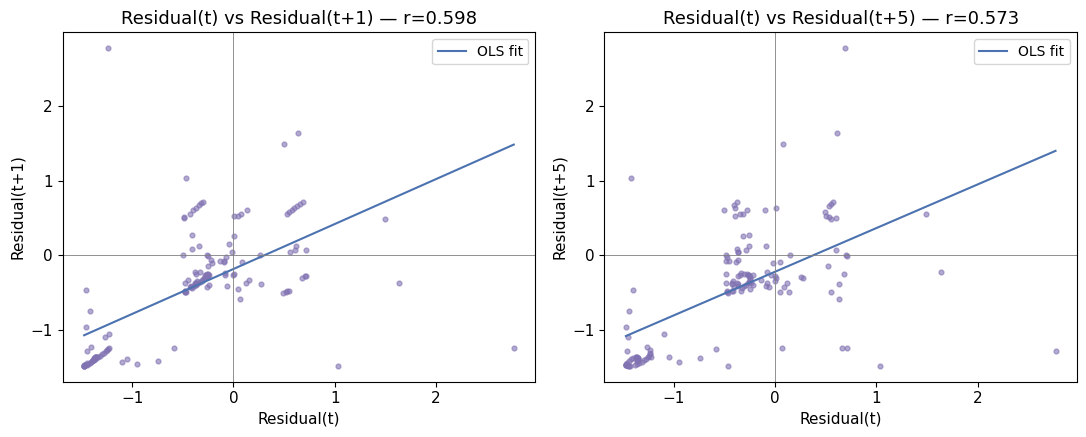

In [42]:
rep_residuals = container_results[REPRESENTATIVE_CONTAINER]["residual_real"]
rep_residuals = rep_residuals[np.isfinite(rep_residuals)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, lag, title in zip(
    axes,
    [1, 5],
    ["Residual(t) vs Residual(t+1)", "Residual(t) vs Residual(t+5)"],
):
    x = rep_residuals[:-lag]
    y = rep_residuals[lag:]
    ax.scatter(x, y, s=12, alpha=0.6, color=COLOR_RESIDUAL)
    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, slope * xs + intercept, color=COLOR_PRED, linewidth=1.5, label="OLS fit")
    corr = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
    ax.set_title(f"{title} — r={corr:.3f}")
    ax.set_xlabel("Residual(t)")
    ax.set_ylabel(f"Residual(t+{lag})")
    ax.axhline(0, color=COLOR_ZERO, linewidth=0.6)
    ax.axvline(0, color=COLOR_ZERO, linewidth=0.6)
    ax.legend()
plt.tight_layout()
plt.show()


**Interpretation (Section 9):** Visible diagonal structure or concentratedclouds away from the origin indicate lagged predictability. Near-zero correlationwith a diffuse scatter suggests weak linear lag dependence (though nonlinearpatterns may still exist for the GRU).

## Section 10 — Rolling StatisticsOne-day rolling mean and standard deviation of validation residuals for therepresentative container. Changing variance over time indicates heteroscedasticerror regimes (e.g., burst periods).

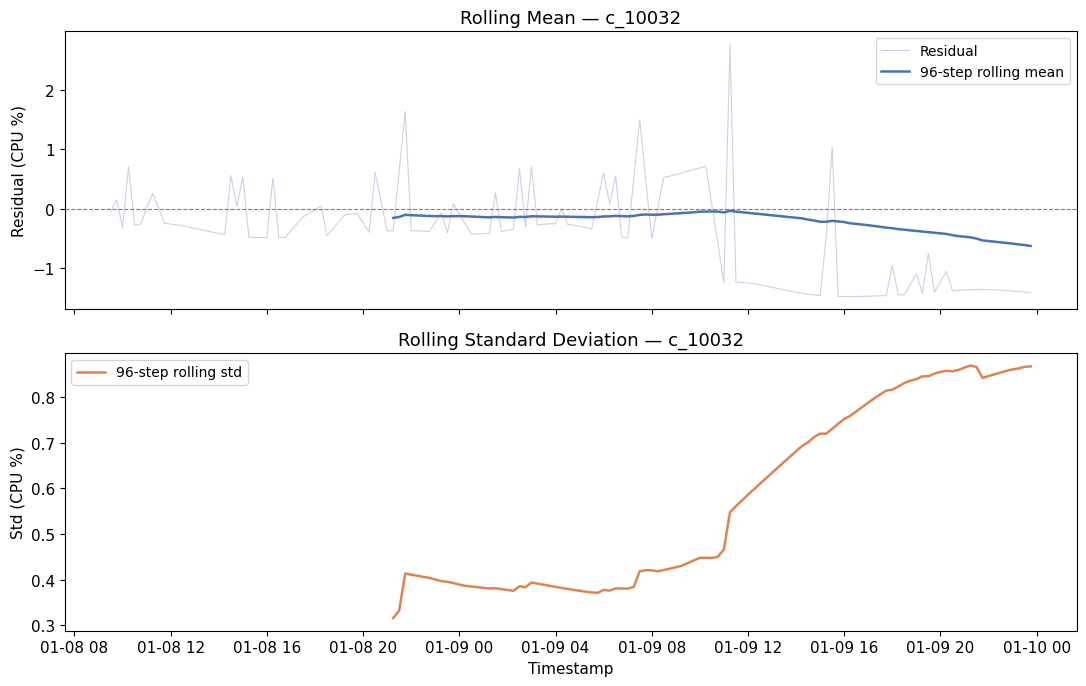

Rolling std range: [0.3157, 0.8694] %


In [43]:
rep_ts = pd.Series(
    container_results[REPRESENTATIVE_CONTAINER]["residual_real"],
    index=pd.to_datetime(container_results[REPRESENTATIVE_CONTAINER]["timestamps"]),
)

rolling_mean = rep_ts.rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW // 2).mean()
rolling_std = rep_ts.rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW // 2).std()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(rep_ts.index, rep_ts.values, color=COLOR_RESIDUAL, alpha=0.35, linewidth=0.8, label="Residual")
axes[0].plot(rolling_mean.index, rolling_mean.values, color=COLOR_PRED, linewidth=1.8, label=f"{ROLLING_WINDOW}-step rolling mean")
axes[0].axhline(0.0, color=COLOR_ZERO, linestyle="--", linewidth=0.8)
axes[0].set_title(f"Rolling Mean — {REPRESENTATIVE_CONTAINER}")
axes[0].set_ylabel("Residual (CPU %)")
axes[0].legend()

axes[1].plot(rolling_std.index, rolling_std.values, color=COLOR_PROPHET, linewidth=1.8, label=f"{ROLLING_WINDOW}-step rolling std")
axes[1].set_title(f"Rolling Standard Deviation — {REPRESENTATIVE_CONTAINER}")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Std (CPU %)")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Rolling std range: [{rolling_std.min():.4f}, {rolling_std.max():.4f}] %")


**Interpretation (Section 10):** Rising rolling variance indicates periodswhere Prophet errors amplify — often during workload transitions or peaks.Stable variance suggests approximately homogeneous residual noise.

## Section 11 — Frequency AnalysisPeriodogram of validation residuals to detect remaining periodic componentsafter Prophet's daily seasonality term.

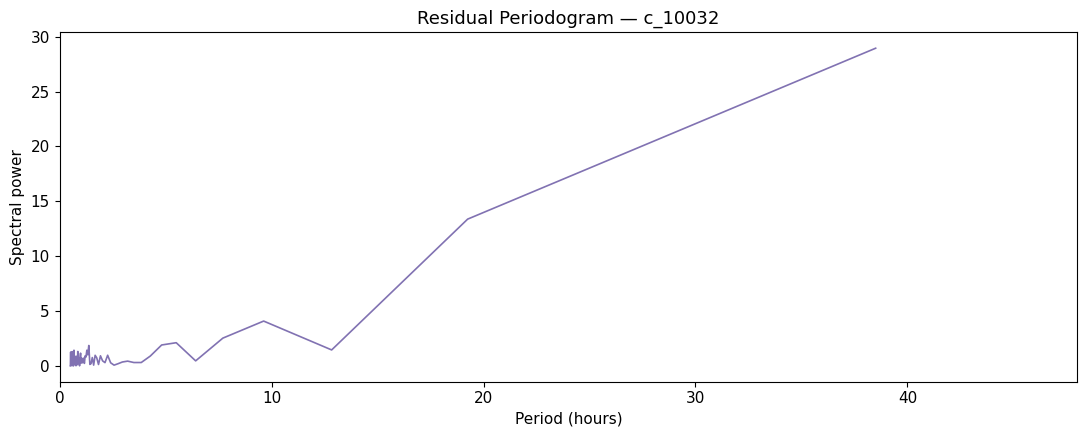

Dominant periods (hours):
  period ≈ 38.50 h, power=2.896e+01
  period ≈ 19.25 h, power=1.338e+01
  period ≈ 9.62 h, power=4.081e+00


In [44]:
series = container_results[REPRESENTATIVE_CONTAINER]["residual_real"]
series = series[np.isfinite(series)]

freqs, power = periodogram(series, fs=1.0)

# Convert frequency (steps^-1) to period in hours (15-min steps -> 4 steps/hour)
with np.errstate(divide="ignore"):
    periods_hours = np.where(freqs > 0, 1.0 / (freqs * 4.0), np.inf)

fig, ax = plt.subplots()
ax.plot(periods_hours[1:], power[1:], color=COLOR_RESIDUAL, linewidth=1.2)
ax.set_xlim(0, 48)
ax.set_title(f"Residual Periodogram — {REPRESENTATIVE_CONTAINER}")
ax.set_xlabel("Period (hours)")
ax.set_ylabel("Spectral power")
plt.tight_layout()
plt.show()

top_idx = np.argsort(power[1:])[-3:][::-1] + 1
print("Dominant periods (hours):")
for idx in top_idx:
    if freqs[idx] > 0:
        print(f"  period ≈ {periods_hours[idx]:.2f} h, power={power[idx]:.3e}")


**Interpretation (Section 11):** Peaks near 24 h suggest incomplete dailyseasonality removal. Shorter-period peaks may reflect sub-daily workload cyclesnot fully captured by Prophet's default daily Fourier terms.

## Section 12 — Prophet vs Residual VisualizationAligned view of actual CPU, Prophet forecast, and validation residuals.Large Prophet errors (|residual| spikes) highlight timesteps where GRUcorrection is most valuable.

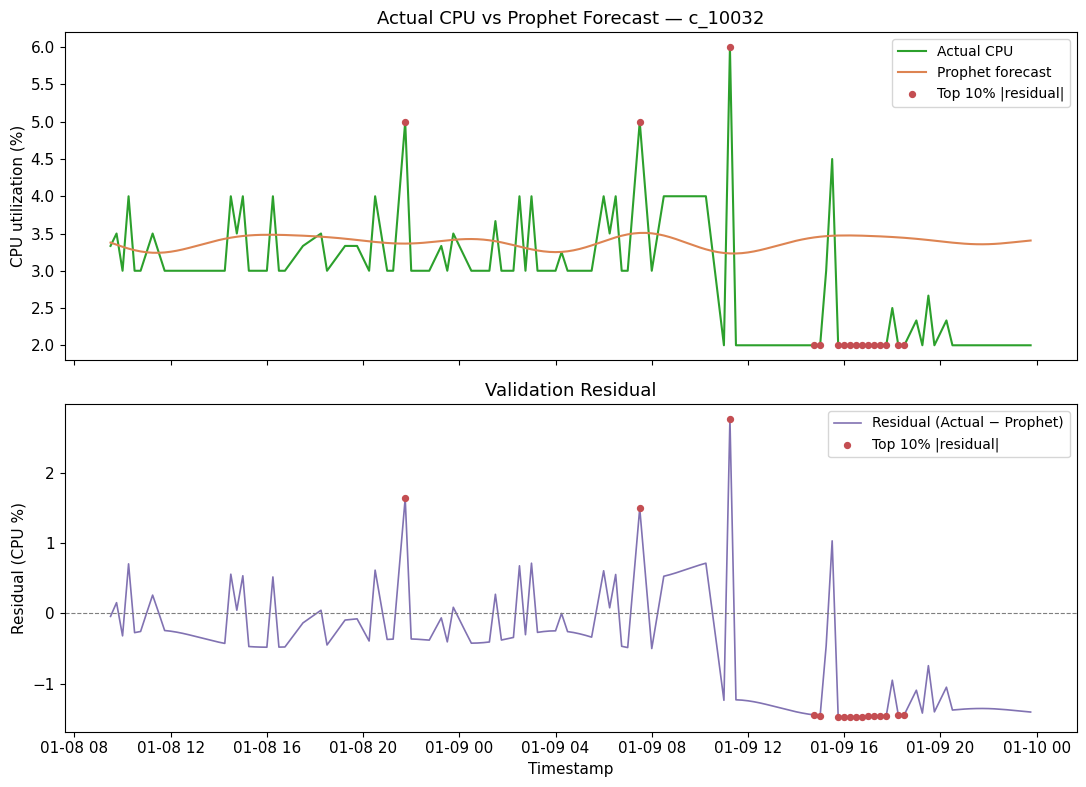

In [45]:
rep = container_results[REPRESENTATIVE_CONTAINER]
ts = pd.to_datetime(rep["timestamps"])
actual = rep["actual_real"]
prophet = rep["prophet_real"]
residual = rep["residual_real"]

error_threshold = np.nanpercentile(np.abs(residual), 90)
highlight = np.abs(residual) >= error_threshold

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(ts, actual, label="Actual CPU", color=COLOR_ACTUAL, linewidth=1.5)
axes[0].plot(ts, prophet, label="Prophet forecast", color=COLOR_PROPHET, linewidth=1.5)
axes[0].scatter(ts[highlight], actual[highlight], color="#C44E52", s=18, zorder=3, label="Top 10% |residual|")
axes[0].set_title(f"Actual CPU vs Prophet Forecast — {REPRESENTATIVE_CONTAINER}")
axes[0].set_ylabel("CPU utilization (%)")
axes[0].legend()

axes[1].plot(ts, residual, label="Residual (Actual − Prophet)", color=COLOR_RESIDUAL, linewidth=1.2)
axes[1].scatter(ts[highlight], residual[highlight], color="#C44E52", s=18, zorder=3, label="Top 10% |residual|")
axes[1].axhline(0.0, color=COLOR_ZERO, linestyle="--", linewidth=0.8)
axes[1].set_title("Validation Residual")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Residual (CPU %)")
axes[1].legend()
plt.tight_layout()
plt.show()


**Interpretation (Section 12):** Co-occurring Prophet misses and largeresiduals confirm structured error regions. If spikes align with workloadbursts, a residual learner can target the highest-impact timesteps.

## Section 13 — Residual Prediction QualityLoad the **frozen** Hybrid GRU (no retraining). Compare Day-1 predictedresiduals against actual validation residuals in scaled space (matchingGRU training), then report MAE, RMSE, Pearson r, and R².

00:56:03 - cmdstanpy - INFO - Chain [1] start processing
00:56:03 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


00:56:03 - cmdstanpy - INFO - Chain [1] start processing
00:56:03 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


00:56:03 - cmdstanpy - INFO - Chain [1] start processing
00:56:03 - cmdstanpy - INFO - Chain [1] done processing


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


00:56:26 - cmdstanpy - INFO - Chain [1] start processing
00:56:26 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


00:56:26 - cmdstanpy - INFO - Chain [1] start processing
00:56:26 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
GRU residual prediction quality (scaled residual space, Day-1):
container_id  residual_mae_scaled  residual_rmse_scaled  pearson_r        r2
     c_10032             0.052314              0.064118   0.047269 -0.021731
     c_10034             0.119875              0.134667   0.556413 -0.016644
     c_10089             0.054813              0.073147  -0.016008 -0.114470
     c_10132             0.154043              0.190672   0.059485 -0.009685
      c_1016             0.024843              0.036709  -0.198219 -0.017669
     c_10306             0.099970              0.114580  -0.208260 -0.012857
     c_10312             0.009123              0.011723   0.326587 -0.112721
     c_10382             0.068869              0.099085   0.029785 -0.019604
     c_10393             0.054910              0.071128  -0.096881 -0.008220
     c_10641             0.027923              0.036685   0.025422 -0.352113
     c_10695 

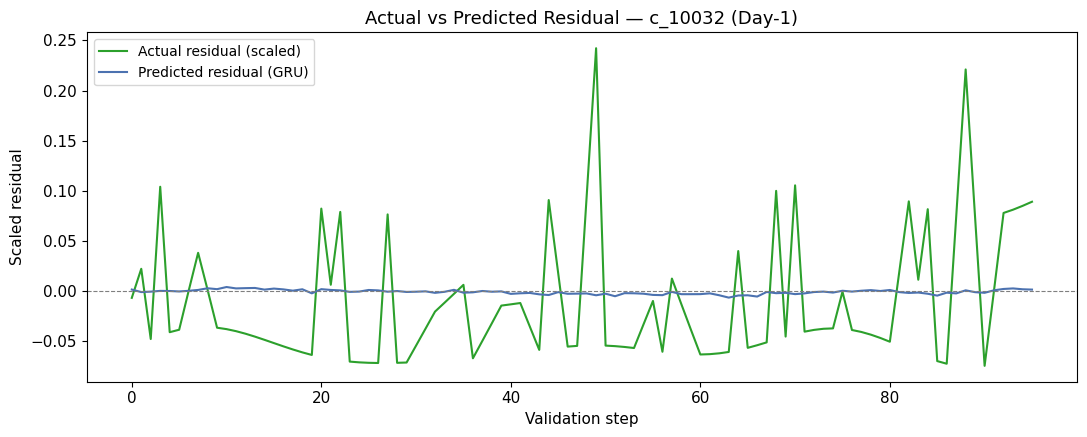

In [46]:
gru_rows = []

for cid in analysed_containers:
    result = run_hybrid_inference(
        container_id=cid,
        global_train=train_df,
        global_val=val_df,
        hybrid_gru_model=hybrid_gru_model,
        scalers=scalers,
        res_mean=res_mean,
        res_std=res_std,
        input_window=INPUT_WINDOW,
        day1_horizon=DAY1_HORIZON,
    )

    actual_res = result.actual_day1_scaled - result.day1_prophet
    pred_res = result.day1_residual

    mae = float(mean_absolute_error(actual_res, pred_res))
    rmse = float(np.sqrt(mean_squared_error(actual_res, pred_res)))
    if np.std(actual_res) > 0 and np.std(pred_res) > 0:
        pearson_r = float(np.corrcoef(actual_res, pred_res)[0, 1])
    else:
        pearson_r = float("nan")
    r2 = float(r2_score(actual_res, pred_res))

    hybrid_residual_real = result.actual_day1_real - result.day1_final_real

    gru_rows.append({
        "container_id": cid,
        "residual_mae_scaled": mae,
        "residual_rmse_scaled": rmse,
        "pearson_r": pearson_r,
        "r2": r2,
        "actual_res": actual_res,
        "pred_res": pred_res,
        "hybrid_final_real": result.day1_final_real,
        "hybrid_residual_real": hybrid_residual_real,
        "hybrid_mae": float(mean_absolute_error(result.actual_day1_real, result.day1_final_real)),
    })

gru_df = pd.DataFrame(gru_rows)

hybrid_container_results: dict[str, dict] = {}
for _, row in gru_df.iterrows():
    hybrid_container_results[row["container_id"]] = {
        "hybrid_residual_real": row["hybrid_residual_real"],
        "hybrid_final_real": row["hybrid_final_real"],
        "hybrid_mae": row["hybrid_mae"],
    }
print("GRU residual prediction quality (scaled residual space, Day-1):")
print(gru_df[["container_id", "residual_mae_scaled", "residual_rmse_scaled", "pearson_r", "r2"]].to_string(index=False))
print()
print("Cohort averages:")
print(f"  Residual MAE  : {gru_df['residual_mae_scaled'].mean():.6f}")
print(f"  Residual RMSE : {gru_df['residual_rmse_scaled'].mean():.6f}")
print(f"  Pearson r     : {gru_df['pearson_r'].mean():.4f}")
print(f"  R²            : {gru_df['r2'].mean():.4f}")

rep_gru = gru_df[gru_df["container_id"] == REPRESENTATIVE_CONTAINER].iloc[0]
steps = np.arange(len(rep_gru["actual_res"]))

fig, ax = plt.subplots()
ax.plot(steps, rep_gru["actual_res"], label="Actual residual (scaled)", color=COLOR_ACTUAL, linewidth=1.5)
ax.plot(steps, rep_gru["pred_res"], label="Predicted residual (GRU)", color=COLOR_PRED, linewidth=1.5)
ax.axhline(0.0, color=COLOR_ZERO, linestyle="--", linewidth=0.8)
ax.set_title(f"Actual vs Predicted Residual — {REPRESENTATIVE_CONTAINER} (Day-1)")
ax.set_xlabel("Validation step")
ax.set_ylabel("Scaled residual")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation (Section 13):**- **Case A:** Residual diagnostics show structure *and* GRU predictions track  actual residuals (high r, positive R²) → residual learning is effective.- **Case B:** Structure exists but GRU correlation is weak → architecture or  training may not fully exploit residual patterns.- **Case C:** Weak ACF / Ljung–Box failures with low GRU correlation →  residuals approximate white noise; Prophet may already explain most signal.

## Section 14 — Overall Summary (Prophet Residuals)

Concise research summary synthesising **Prophet-only** validation residuals (`Actual − Prophet`, full validation window) across analysed containers.

> **Note:** Sections 5–8 white-noise tests apply to residuals **after Prophet only**. Section 15 repeats the same diagnostics on residuals **after the full Hybrid forecast** (`Actual − Hybrid`, Day-1 window).

In [50]:
avg_prophet_mae = float(np.mean([container_results[c]["prophet_mae"] for c in analysed_containers]))
avg_acf_short = float(acf_summary["lag_1_10"].mean())
reject_rate_20 = float((ljung_df["lb_p_lag_20"] < 0.05).mean())
avg_pearson = float(gru_df["pearson_r"].mean())
avg_r2 = float(gru_df["r2"].mean())

print("=" * 60)
print("RESIDUAL PATTERN ANALYSIS — SUMMARY")
print("=" * 60)
print(f"Analysed containers              : {len(analysed_containers)}")
print(f"Average Prophet MAE (CPU %)      : {avg_prophet_mae:.4f}")
print(f"Pooled residual mean (CPU %)     : {dist_stats['mean']:.4f}")
print(f"Pooled residual variance         : {dist_stats['std'] ** 2:.4f}")
print(f"Average |ACF| lags 1–10          : {avg_acf_short:.4f}")
print(f"Containers rejecting white noise : {reject_rate_20 * 100:.1f}% (Ljung–Box lag 20, p<0.05)")
print(f"GRU residual Pearson r (mean)    : {avg_pearson:.4f}")
print(f"GRU residual R² (mean)           : {avg_r2:.4f}")
print("=" * 60)

# Automated conclusion selection
has_temporal_structure = (avg_acf_short > 0.05) and (reject_rate_20 >= 0.5)
gru_effective = (avg_pearson > 0.3) and (avg_r2 > 0.0)

if has_temporal_structure and gru_effective:
    conclusion = (
        "Conclusion A: The Prophet residuals exhibit statistically significant "
        "temporal dependence across the analysed training containers, supporting "
        "the use of a GRU for residual forecasting."
    )
elif has_temporal_structure and not gru_effective:
    conclusion = (
        "Conclusion C: The residuals contain temporal structure, but the current GRU "
        "does not fully exploit it, indicating room for improving the residual-learning "
        "component."
    )
else:
    conclusion = (
        "Conclusion B: The Prophet residuals contain limited temporal structure, "
        "suggesting Prophet has already captured most predictable behaviour."
    )

print()
print(conclusion)


RESIDUAL PATTERN ANALYSIS — SUMMARY
Analysed containers              : 99
Average Prophet MAE (CPU %)      : 1.8474
Pooled residual mean (CPU %)     : -0.0302
Pooled residual variance         : 19.7827
Average |ACF| lags 1–10          : 0.2010
Containers rejecting white noise : 73.7% (Ljung–Box lag 20, p<0.05)
GRU residual Pearson r (mean)    : 0.0215
GRU residual R² (mean)           : -0.3410

Conclusion C: The residuals contain temporal structure, but the current GRU does not fully exploit it, indicating room for improving the residual-learning component.


## Section 15 — Hybrid Post-Forecast Residual Diagnostics

After the frozen Hybrid model (`Prophet + GRU`), compute the **final forecast error**:

`Hybrid residual = Actual − Hybrid final forecast`

Scope matches Section 13: **Day-1 only** (first `DAY1_HORIZON` validation steps). The same diagnostics as Sections 5–8 are applied:

- Pooled distribution (mean, variance, skewness, kurtosis)
- ACF / PACF cohort averages
- Ljung–Box white-noise rejection rates

For a direct apples-to-apples comparison, Prophet-only residuals are also recomputed on the **same Day-1 window** alongside Hybrid residuals.


Day-1 residual diagnostics comparison (CPU % space):
                                                     metric  prophet_day1  hybrid_day1
                               Pooled residual mean (CPU %)        0.0834       0.0827
                                   Pooled residual variance       15.6362      15.9530
                                    Average |ACF| lags 1–10        0.1889       0.1899
                                   Average |PACF| lags 1–10        0.1146       0.1135
Containers rejecting white noise (Ljung–Box lag 20, p<0.05)       56.5657      54.5455
                                     Mean Day-1 MAE (CPU %)        1.7333       1.7459

Ljung–Box summary — Prophet Day-1 residuals:
  Lag 10:  64.6% reject white noise
  Lag 20:  56.6% reject white noise
  Lag 30:  56.6% reject white noise

Ljung–Box summary — Hybrid Day-1 residuals:
  Lag 10:  64.6% reject white noise
  Lag 20:  54.5% reject white noise
  Lag 30:  56.6% reject white noise


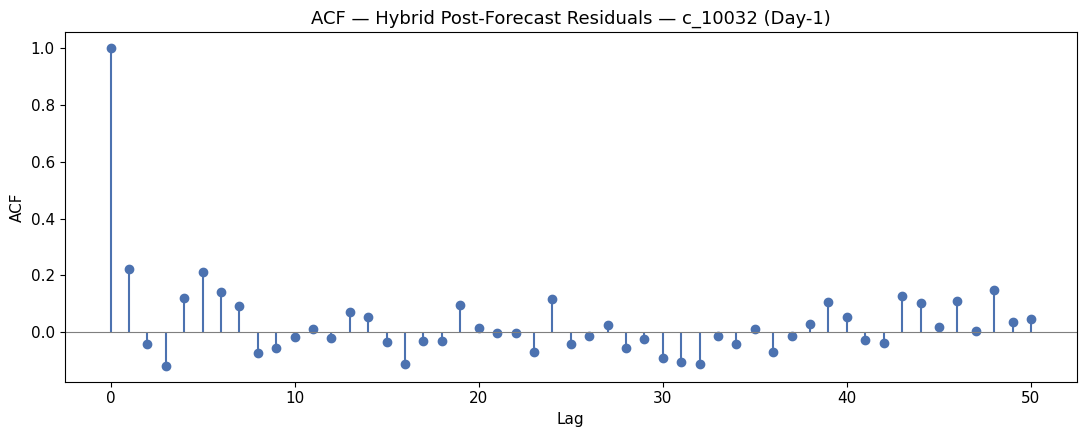

In [51]:
def _residual_diagnostics(
    residual_map: dict[str, np.ndarray],
    label: str,
) -> dict:
    """Compute pooled distribution + ACF/PACF/Ljung metrics for a residual dict."""
    pooled = np.concatenate([
        residual_map[cid] for cid in analysed_containers if cid in residual_map
    ])
    pooled = pooled[np.isfinite(pooled)]

    dist = {
        "mean": float(np.mean(pooled)),
        "median": float(np.median(pooled)),
        "std": float(np.std(pooled)),
        "min": float(np.min(pooled)),
        "max": float(np.max(pooled)),
        "skewness": float(stats.skew(pooled)),
        "kurtosis": float(stats.kurtosis(pooled)),
    }

    acf_rows: list[dict] = []
    pacf_rows: list[dict] = []
    ljung_local: list[dict] = []

    min_series_len = max(ACF_NLAGS, max(LJUNG_LAGS) + 1)

    for cid in analysed_containers:
        if cid not in residual_map:
            continue
        series = residual_map[cid]
        series = series[np.isfinite(series)]
        if len(series) <= min_series_len:
            continue

        acf_nlags = min(ACF_NLAGS, len(series) - 1)
        # PACF requires nlags < 50% of sample size (statsmodels constraint)
        pacf_nlags = min(ACF_NLAGS, (len(series) // 2) - 1)
        if pacf_nlags < 10:
            continue

        acf_vals = acf(series, nlags=acf_nlags, fft=True)
        pacf_vals = pacf(series, nlags=pacf_nlags, method="ywm")
        acf_long_end = min(50, acf_nlags)
        pacf_long_end = min(20, pacf_nlags)
        acf_rows.append({
            "lag_1_10": _avg_abs_acf_range(acf_vals, 1, 10),
            "lag_11_20": _avg_abs_acf_range(acf_vals, 11, min(20, acf_nlags)),
            "lag_21_50": _avg_abs_acf_range(acf_vals, 21, acf_long_end) if acf_nlags >= 21 else float("nan"),
        })
        pacf_rows.append({
            "pacf_lag_1_10": _avg_abs_acf_range(pacf_vals, 1, 10),
            "pacf_lag_11_20": _avg_abs_acf_range(pacf_vals, 11, pacf_long_end) if pacf_nlags >= 11 else float("nan"),
        })

        lb_row = {"container_id": cid}
        for lag in LJUNG_LAGS:
            lb = acorr_ljungbox(series, lags=[lag], return_df=True)
            lb_row[f"lb_p_lag_{lag}"] = float(lb["lb_pvalue"].iloc[0])
        ljung_local.append(lb_row)

    acf_df = pd.DataFrame(acf_rows)
    pacf_df = pd.DataFrame(pacf_rows)
    ljung_local_df = pd.DataFrame(ljung_local)

    return {
        "label": label,
        "n_containers": len(residual_map),
        "dist_stats": dist,
        "avg_acf_lag_1_10": float(acf_df["lag_1_10"].mean()) if not acf_df.empty else float("nan"),
        "avg_acf_lag_11_20": float(acf_df["lag_11_20"].mean()) if not acf_df.empty else float("nan"),
        "avg_acf_lag_21_50": float(acf_df["lag_21_50"].mean()) if not acf_df.empty else float("nan"),
        "avg_pacf_lag_1_10": float(pacf_df["pacf_lag_1_10"].mean()) if not pacf_df.empty else float("nan"),
        "avg_pacf_lag_11_20": float(pacf_df["pacf_lag_11_20"].mean()) if not pacf_df.empty else float("nan"),
        "ljung_reject_lag_10": float((ljung_local_df["lb_p_lag_10"] < 0.05).mean()) if not ljung_local_df.empty else float("nan"),
        "ljung_reject_lag_20": float((ljung_local_df["lb_p_lag_20"] < 0.05).mean()) if not ljung_local_df.empty else float("nan"),
        "ljung_reject_lag_30": float((ljung_local_df["lb_p_lag_30"] < 0.05).mean()) if not ljung_local_df.empty else float("nan"),
        "ljung_df": ljung_local_df,
    }


prophet_day1_residual_map = {
    cid: container_results[cid]["residual_real"][:DAY1_HORIZON]
    for cid in analysed_containers
}
hybrid_day1_residual_map = {
    cid: hybrid_container_results[cid]["hybrid_residual_real"]
    for cid in analysed_containers
}

prophet_day1_diag = _residual_diagnostics(prophet_day1_residual_map, "Prophet (Day-1)")
hybrid_day1_diag = _residual_diagnostics(hybrid_day1_residual_map, "Hybrid (Day-1)")

comparison_rows = [
    {
        "metric": "Pooled residual mean (CPU %)",
        "prophet_day1": prophet_day1_diag["dist_stats"]["mean"],
        "hybrid_day1": hybrid_day1_diag["dist_stats"]["mean"],
    },
    {
        "metric": "Pooled residual variance",
        "prophet_day1": prophet_day1_diag["dist_stats"]["std"] ** 2,
        "hybrid_day1": hybrid_day1_diag["dist_stats"]["std"] ** 2,
    },
    {
        "metric": "Average |ACF| lags 1–10",
        "prophet_day1": prophet_day1_diag["avg_acf_lag_1_10"],
        "hybrid_day1": hybrid_day1_diag["avg_acf_lag_1_10"],
    },
    {
        "metric": "Average |PACF| lags 1–10",
        "prophet_day1": prophet_day1_diag["avg_pacf_lag_1_10"],
        "hybrid_day1": hybrid_day1_diag["avg_pacf_lag_1_10"],
    },
    {
        "metric": "Containers rejecting white noise (Ljung–Box lag 20, p<0.05)",
        "prophet_day1": prophet_day1_diag["ljung_reject_lag_20"] * 100,
        "hybrid_day1": hybrid_day1_diag["ljung_reject_lag_20"] * 100,
    },
    {
        "metric": "Mean Day-1 MAE (CPU %)",
        "prophet_day1": float(np.mean([
            mean_absolute_error(
                container_results[cid]["actual_real"][:DAY1_HORIZON],
                container_results[cid]["prophet_real"][:DAY1_HORIZON],
            )
            for cid in analysed_containers
        ])),
        "hybrid_day1": float(np.mean([
            hybrid_container_results[cid]["hybrid_mae"] for cid in analysed_containers
        ])),
    },
]
comparison_df = pd.DataFrame(comparison_rows)

print("Day-1 residual diagnostics comparison (CPU % space):")
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nLjung–Box summary — Prophet Day-1 residuals:")
for lag in LJUNG_LAGS:
    rate = prophet_day1_diag[f"ljung_reject_lag_{lag}"] * 100
    print(f"  Lag {lag:2d}: {rate:5.1f}% reject white noise")

print("\nLjung–Box summary — Hybrid Day-1 residuals:")
for lag in LJUNG_LAGS:
    rate = hybrid_day1_diag[f"ljung_reject_lag_{lag}"] * 100
    print(f"  Lag {lag:2d}: {rate:5.1f}% reject white noise")

rep_hybrid_res = hybrid_day1_residual_map[REPRESENTATIVE_CONTAINER]
rep_acf_nlags = min(ACF_NLAGS, len(rep_hybrid_res) - 1)
rep_hybrid_acf = acf(rep_hybrid_res, nlags=rep_acf_nlags, fft=True)
fig, ax = plt.subplots()
ax.stem(np.arange(len(rep_hybrid_acf)), rep_hybrid_acf, linefmt=COLOR_PRED, markerfmt="o", basefmt=" ")
ax.axhline(0.0, color=COLOR_ZERO, linewidth=0.8)
ax.set_title(f"ACF — Hybrid Post-Forecast Residuals — {REPRESENTATIVE_CONTAINER} (Day-1)")
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
plt.tight_layout()
plt.show()


## Section 16 — Side-by-Side Summary (Prophet vs Hybrid Residuals)

Prints the same headline matrix as Section 14 for **both** residual stages:

1. **Prophet-only** (full validation window — Sections 5–8)
2. **Hybrid post-forecast** (Day-1 window — Section 15)

Lower Ljung–Box rejection rate and |ACF| on Hybrid residuals would indicate the GRU removed temporal structure left by Prophet. If metrics stay similar, the Hybrid correction is mostly a small bias shift rather than dynamic residual modelling.


In [52]:
avg_hybrid_mae_day1 = float(np.mean([
    hybrid_container_results[cid]["hybrid_mae"] for cid in analysed_containers
]))
hybrid_dist = hybrid_day1_diag["dist_stats"]
hybrid_acf_short = hybrid_day1_diag["avg_acf_lag_1_10"]
hybrid_reject_rate_20 = hybrid_day1_diag["ljung_reject_lag_20"]

print("=" * 60)
print("PROPHET RESIDUALS — SUMMARY (full validation window)")
print("=" * 60)
print(f"Analysed containers              : {len(analysed_containers)}")
print(f"Average Prophet MAE (CPU %)      : {avg_prophet_mae:.4f}")
print(f"Pooled residual mean (CPU %)     : {dist_stats['mean']:.4f}")
print(f"Pooled residual variance         : {dist_stats['std'] ** 2:.4f}")
print(f"Average |ACF| lags 1–10          : {avg_acf_short:.4f}")
print(f"Containers rejecting white noise : {reject_rate_20 * 100:.1f}% (Ljung–Box lag 20, p<0.05)")
print(f"GRU residual Pearson r (mean)    : {avg_pearson:.4f}")
print(f"GRU residual R² (mean)           : {avg_r2:.4f}")
print("=" * 60)
print()
print(conclusion)
print()

print("=" * 60)
print("HYBRID POST-FORECAST RESIDUALS — SUMMARY (Day-1 window)")
print("=" * 60)
print(f"Analysed containers              : {len(analysed_containers)}")
print(f"Average Hybrid Day-1 MAE (CPU %) : {avg_hybrid_mae_day1:.4f}")
print(f"Pooled residual mean (CPU %)     : {hybrid_dist['mean']:.4f}")
print(f"Pooled residual variance         : {hybrid_dist['std'] ** 2:.4f}")
print(f"Average |ACF| lags 1–10          : {hybrid_acf_short:.4f}")
print(f"Containers rejecting white noise : {hybrid_reject_rate_20 * 100:.1f}% (Ljung–Box lag 20, p<0.05)")
print(f"Average |PACF| lags 1–10         : {hybrid_day1_diag['avg_pacf_lag_1_10']:.4f}")
print("=" * 60)

hybrid_has_structure = (hybrid_acf_short > 0.05) and (hybrid_reject_rate_20 >= 0.5)
if hybrid_has_structure:
    hybrid_conclusion = (
        "Hybrid post-forecast residuals still show temporal structure on Day-1; "
        "the frozen GRU did not fully whiten Prophet errors."
    )
else:
    hybrid_conclusion = (
        "Hybrid post-forecast residuals are closer to white noise on Day-1 than Prophet-only "
        "residuals, consistent with partial error correction by the GRU path."
    )

print()
print(hybrid_conclusion)


PROPHET RESIDUALS — SUMMARY (full validation window)
Analysed containers              : 99
Average Prophet MAE (CPU %)      : 1.8474
Pooled residual mean (CPU %)     : -0.0302
Pooled residual variance         : 19.7827
Average |ACF| lags 1–10          : 0.2010
Containers rejecting white noise : 73.7% (Ljung–Box lag 20, p<0.05)
GRU residual Pearson r (mean)    : 0.0215
GRU residual R² (mean)           : -0.3410

Conclusion C: The residuals contain temporal structure, but the current GRU does not fully exploit it, indicating room for improving the residual-learning component.

HYBRID POST-FORECAST RESIDUALS — SUMMARY (Day-1 window)
Analysed containers              : 99
Average Hybrid Day-1 MAE (CPU %) : 1.7459
Pooled residual mean (CPU %)     : 0.0827
Pooled residual variance         : 15.9530
Average |ACF| lags 1–10          : 0.1899
Containers rejecting white noise : 54.5% (Ljung–Box lag 20, p<0.05)
Average |PACF| lags 1–10         : 0.1135

Hybrid post-forecast residuals still show te